In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

# 입력 문장
tokens = ["The", "cat", "sat", "on", "the", "mat"]
vocab = {word: idx for idx, word in enumerate(tokens)}
vocab_size = len(vocab)
embed_dim = 8

# 임베딩 벡터 정의 (고정값 사용)
torch.manual_seed(42)
embedding = nn.Embedding(vocab_size, embed_dim)
inputs = torch.tensor([vocab[word] for word in tokens])  # (seq_len,)
embedded = embedding(inputs).unsqueeze(0)  # (1, seq_len, embed_dim)
print("입력 벡터 shape:", embedded.shape)


입력 벡터 shape: torch.Size([1, 6, 8])


In [10]:
class SelfAttention(nn.Module):
    def __init__(self, embed_dim):
        super().__init__()
        self.q_proj = nn.Linear(embed_dim, embed_dim)
        self.k_proj = nn.Linear(embed_dim, embed_dim)
        self.v_proj = nn.Linear(embed_dim, embed_dim)
        self.scale = np.sqrt(embed_dim)

    def forward(self, x):
        Q = self.q_proj(x)
        K = self.k_proj(x)
        V = self.v_proj(x)

        scores = torch.matmul(Q, K.transpose(-2, -1)) / self.scale
        attn_weights = F.softmax(scores, dim=-1)
        output = torch.matmul(attn_weights, V)
        return output, attn_weights


In [11]:
sa = SelfAttention(embed_dim=embed_dim)
output, attn_weights = sa(embedded)

print("Output shape:", output.shape)
print("Attention Weights shape:", attn_weights.shape)


Output shape: torch.Size([1, 6, 8])
Attention Weights shape: torch.Size([1, 6, 6])


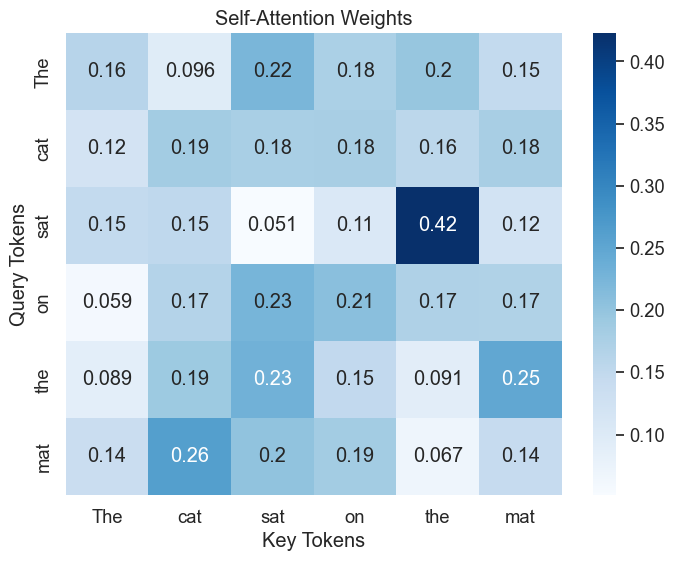

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(font_scale=1.2)
plt.figure(figsize=(8, 6))
sns.heatmap(attn_weights[0].detach().numpy(), xticklabels=tokens, yticklabels=tokens, cmap="Blues", annot=True)
plt.title("Self-Attention Weights")
plt.xlabel("Key Tokens")
plt.ylabel("Query Tokens")
plt.show()


In [22]:
def preprocess_text_file(file_path):
    with open(file_path, "r", encoding="utf-8") as f:
        text = f.read()

    raw_sentences = text.strip().split(".")
    tokenized_sentences = []

    for sent in raw_sentences:
        words = sent.strip() \
            .replace(",", "") \
            .replace(";", "") \
            .replace("’", "'") \
            .replace("“", "") \
            .replace("”", "") \
            .replace("?", "") \
            .replace("!", "") \
            .split()
        if len(words) > 0:
            tokenized_sentences.append(words)
    
    return tokenized_sentences

sentences = preprocess_text_file("cleaned/cleaned_01_Harry.txt")
print(f"Loaded {len(sentences)} sentences.")

for i in range(10):
    print(sentences[i])

Loaded 5358 sentences.
['M', 'r']
['and', 'Mrs']
['Dursley', 'of', 'number', 'four', 'Privet', 'Drive', 'were', 'proud', 'to', 'say', 'that', 'they', 'were', 'perfectly', 'normal', 'thank', 'you', 'very', 'much']
['They', 'were', 'the', 'last', 'people', "you'd", 'expect', 'to', 'be', 'involved', 'in', 'anything', 'strange', 'or', 'mysterious', 'because', 'they', 'just', "didn't", 'hold', 'with', 'such', 'nonsense']
['Mr']
['Dursley', 'was', 'the', 'director', 'of', 'a', 'firm', 'called', 'Grunnings', 'which', 'made', 'drills']
['He', 'was', 'a', 'big', 'beefy', 'man', 'with', 'hardly', 'any', 'neck', 'although', 'he', 'did', 'have', 'a', 'very', 'large', 'mustache']
['Mrs']
['Dursley', 'was', 'thin', 'and', 'blonde', 'and', 'had', 'nearly', 'twice', 'the', 'usual', 'amount', 'of', 'neck', 'which', 'came', 'in', 'very', 'useful', 'as', 'she', 'spent', 'so', 'much', 'of', 'her', 'time', 'craning', 'over', 'garden', 'fences', 'spying', 'on', 'the', 'neighbors']
['The', 'Dursleys', 'had',

In [26]:
def build_vocab(sentences):
    vocab = sorted(set(word for sent in sentences for word in sent))
    vocab.append("<PAD>")
    vocab_dict = {word: idx for idx, word in enumerate(vocab)}
    return vocab_dict

vocab_dict = build_vocab(sentences)
vocab_size = len(vocab_dict)
print(f"Vocab size: {vocab_size}")

Vocab size: 7299


In [27]:
def tokenize_sentences(sentences, vocab_dict, max_len=12):
    encoded = []
    for sent in sentences:
        ids = [vocab_dict[word] for word in sent[:max_len] if word in vocab_dict]
        ids += [vocab_dict["<PAD>"]] * (max_len - len(ids))
        encoded.append(ids)
    return torch.tensor(encoded)

encoded_tensor = tokenize_sentences(sentences[:30], vocab_dict, max_len=12)
print("Encoded shape:", encoded_tensor.shape)


Encoded shape: torch.Size([30, 12])


In [28]:
import torch.nn as nn
import torch.nn.functional as F

class SelfAttention(nn.Module):
    def __init__(self, embed_dim):
        super().__init__()
        self.q_proj = nn.Linear(embed_dim, embed_dim)
        self.k_proj = nn.Linear(embed_dim, embed_dim)
        self.v_proj = nn.Linear(embed_dim, embed_dim)
        self.scale = embed_dim ** 0.5

    def forward(self, x):
        Q = self.q_proj(x)
        K = self.k_proj(x)
        V = self.v_proj(x)
        scores = torch.matmul(Q, K.transpose(-2, -1)) / self.scale
        attn_weights = F.softmax(scores, dim=-1)
        output = torch.matmul(attn_weights, V)
        return output, attn_weights


In [29]:
embed_dim = 16
embedding = nn.Embedding(vocab_size, embed_dim)
embedded_input = embedding(encoded_tensor)  # (batch_size, seq_len, embed_dim)

attention = SelfAttention(embed_dim)
output, attn_weights = attention(embedded_input)
print("Attention shape:", attn_weights.shape)


Attention shape: torch.Size([30, 12, 12])


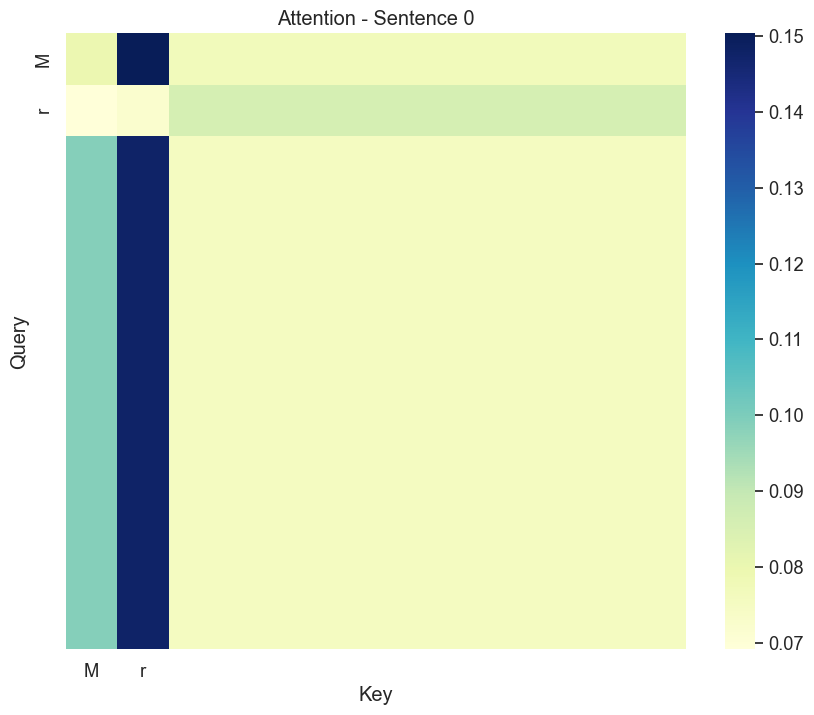

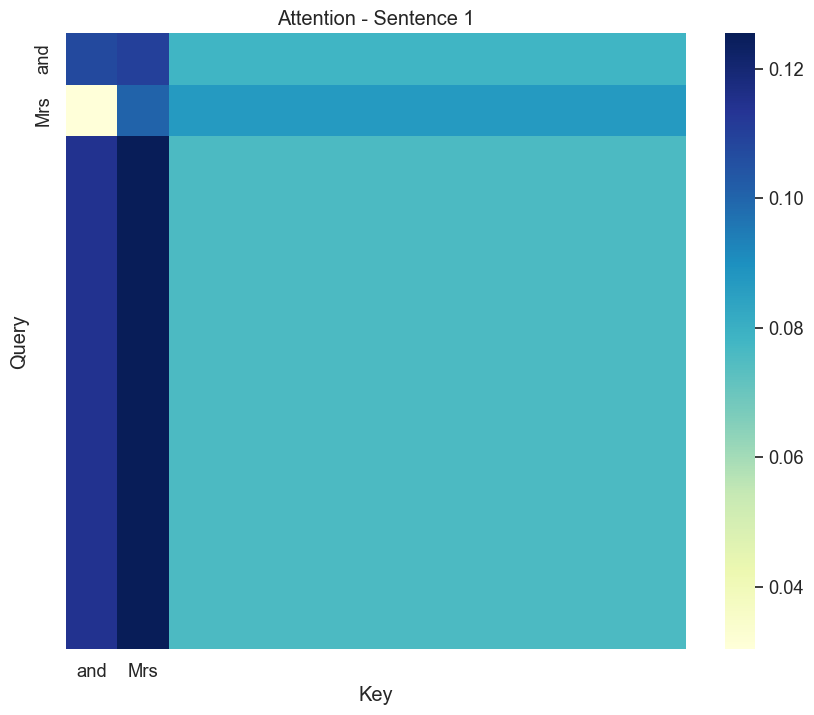

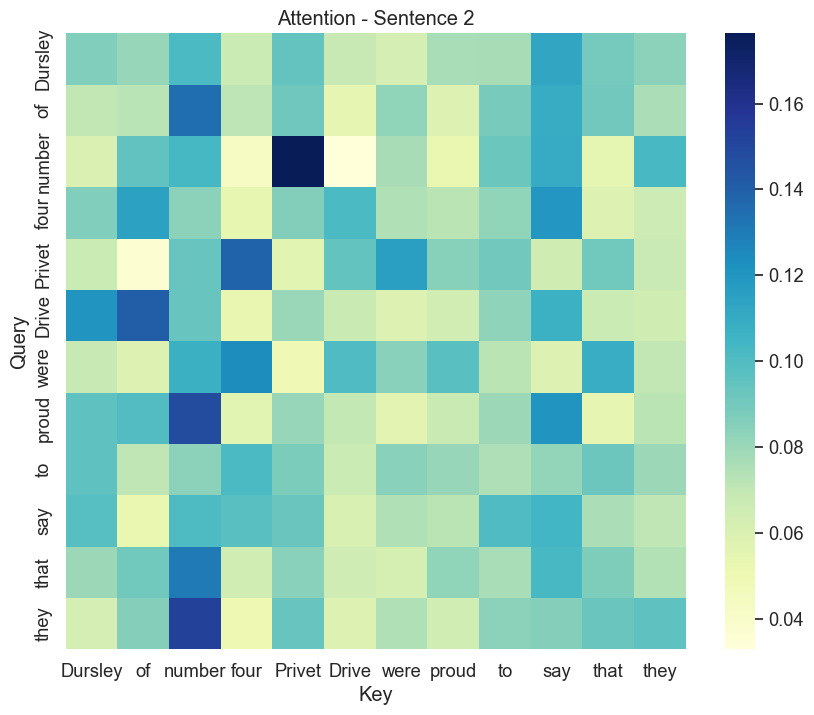

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_attention(attn, tokens, idx):
    sns.set(font_scale=1.2)
    plt.figure(figsize=(10, 8))
    sns.heatmap(attn.detach().numpy(), xticklabels=tokens, yticklabels=tokens, cmap="YlGnBu", annot=False)
    plt.title(f"Attention - Sentence {idx}")
    plt.xlabel("Key")
    plt.ylabel("Query")
    plt.show()

# 예시: 0~2번째 문장
for i in range(3):
    tokens = sentences[i][:12]
    plot_attention(attn_weights[i], tokens, i)


In [77]:
target_word = "Potter"

target_word_sentences = []
original_tokens = []

for sent in sentences:
    if target_word in sent:
        target_word_sentences.append(sent)
        original_tokens.append(sent[:12])

print(f"Total '{target_word}' sentences: {len(target_word_sentences)}")


Total 'Potter' sentences: 98


In [78]:
encoded_tensor = tokenize_sentences(dursley_sentences, vocab_dict, max_len=12)
embedded_input = embedding(encoded_tensor)
output, attn_weights = attention(embedded_input)  # (batch, seq_len, seq_len)

target_index = vocab_dict[target_word]
selected_attn_rows = []

for i, sentence in enumerate(dursley_sentences):
    if target_word in sentence[:12]:
        pos = sentence[:12].index(target_word)
        attn_row = attn_weights[i][pos]  # (seq_len,)
        selected_attn_rows.append(attn_row)

if selected_attn_rows:
    avg_attn = torch.stack(selected_attn_rows, dim=0).mean(dim=0)  # (seq_len,)
else:
    avg_attn = None

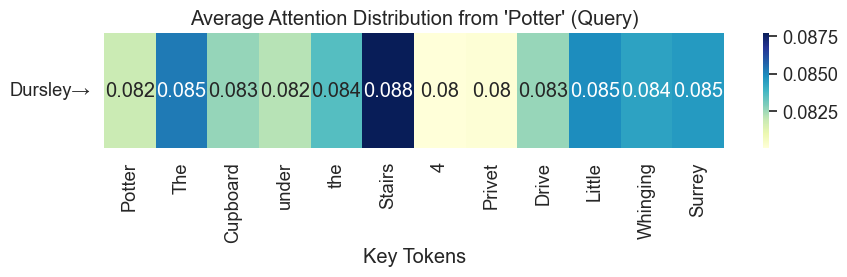

In [79]:
if avg_attn is not None:
    import matplotlib.pyplot as plt
    import seaborn as sns

    # 가장 최근 Dursley 문장의 앞 12개 토큰 기준 시각화
    last_tokens = original_tokens[3:][10]
    sns.set(font_scale=1.2)
    plt.figure(figsize=(10, 1.5))
    sns.heatmap(avg_attn.detach().numpy().reshape(1, -1),
                xticklabels=last_tokens,
                yticklabels=["Dursley→"], cmap="YlGnBu", annot=True)
    plt.title(f"Average Attention Distribution from '{target_word}' (Query)")
    plt.xlabel("Key Tokens")
    plt.yticks(rotation=0)
    plt.show()
else:
    print(f"'{target_word}'가 포함된 문장에서 attention 추출 불가.")

In [81]:
# Target word 등장 문장 단어들을 하나의 리스트로 통합


merged_tokens = []
for sent in target_word_sentences:
    merged_tokens.extend(sent)

print(f"Total tokens in merged sequence: {len(merged_tokens)}")


Total tokens in merged sequence: 1894


In [82]:
# padding 없이 전체 문장을 1개의 시퀀스로 변환
merged_ids = [vocab_dict[token] for token in merged_tokens]
merged_tensor = torch.tensor(merged_ids).unsqueeze(0)  # (1, seq_len)
embedded_merged = embedding(merged_tensor)


In [84]:
output, attn_weights = attention(embedded_merged)  # (1, seq_len, seq_len)

# Dursley 위치 모두 찾기
target_word_indices = [i for i, t in enumerate(merged_tokens) if t == targetKeyword]

print(f"'Potter' appears at positions: {target_word_indices}")

target_word_attn_rows = [attn_weights[0][i] for i in target_word_indices]  # (seq_len,) each
avg_attn_row = torch.stack(targetKeyword_attn_rows).mean(dim=0)  # (seq_len,)

'Potter' appears at positions: [0, 3, 18, 36, 44, 68, 80, 129, 154, 191, 201, 241, 262, 283, 307, 337, 364, 377, 404, 418, 424, 447, 511, 518, 541, 558, 574, 577, 585, 590, 601, 602, 603, 604, 605, 610, 634, 653, 664, 669, 684, 692, 700, 737, 755, 761, 805, 808, 825, 844, 845, 849, 901, 917, 937, 973, 976, 1038, 1086, 1091, 1095, 1108, 1118, 1129, 1143, 1180, 1220, 1235, 1237, 1248, 1271, 1280, 1312, 1322, 1341, 1389, 1405, 1434, 1459, 1475, 1501, 1523, 1527, 1564, 1577, 1587, 1594, 1597, 1615, 1683, 1690, 1741, 1767, 1795, 1807, 1826, 1850, 1856, 1860, 1863, 1868, 1882, 1891]


In [90]:
def plot_top_attention(avg_attn_row, merged_tokens, top_k=15):
    # 상위 top_k 인덱스 추출
    topk_values, topk_indices = torch.topk(avg_attn_row, k=top_k)
    top_tokens = [merged_tokens[i] for i in topk_indices]

    # 시각화
    import matplotlib.pyplot as plt
    import seaborn as sns

    sns.set(font_scale=1.0)
    plt.figure(figsize=(min(20, top_k), 2))
    sns.heatmap(topk_values.detach().numpy().reshape(1, -1),
                xticklabels=top_tokens,
                yticklabels=[target_word],
                cmap="YlGnBu", annot=True)
    plt.title(f"Top {top_k} Attention from '{target_word}'")
    plt.xlabel("Key Tokens")
    plt.yticks(rotation=0)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


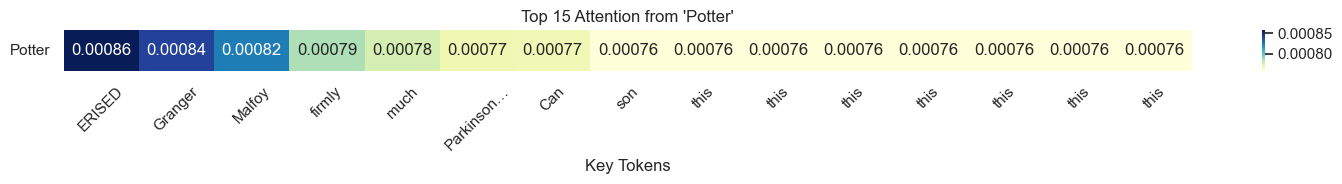

In [91]:
plot_top_attention(avg_attn_row, merged_tokens, top_k=15)